In [1]:
from ioMicro import read_im
import matplotlib.pyplot as plt
import numpy as np
import glob
import zarr
import os

##### Load raw image data

In [2]:
data_folder = r'Y:\Zane_phpeb3week20CRE_6_1_2024'

# map all the hybes
hybes =  glob.glob(data_folder+os.sep+'H*')
# map all the fovs
fovs = [os.path.basename(fl) for fl in glob.glob(hybes[0]+os.sep+'*.zarr')]
def get_Hi(fld): 
    try: return int(os.path.basename(fld)[1:]) 
    except: return -1
    
hybes = np.array(hybes)[np.argsort([get_Hi(hybe) for hybe in hybes ])]
fovs.sort()

zarr_files = r'Y:\Zane_phpeb3week20CRE_6_1_2024\H0_GFP\Conv_zscan__*.zarr'
files = list(sorted(list(glob.glob(zarr_files))))

im_path = r'Y:\Zane_phpeb3week20CRE_6_1_2024\H0_GFP\\*'
imgs = [read_im(im_path) for im_path in files]

##### Load specific enhancer spots in a given FOV

In [33]:
foo = np.load(r'Y:\Zane_phpeb3week20CRE_6_1_2024_final_spots\saveDecodedFinalV1--Zane_phpeb3week20CRE_6_1_2024_MERFISH_Analysis--Conv_zscan__000--.npz',
              allow_pickle=True)

In [155]:
foo

NpzFile 'Y:\\Zane_phpeb3week20CRE_6_1_2024_final_spots\\saveDecodedFinalV1--Zane_phpeb3week20CRE_6_1_2024_MERFISH_Analysis--Conv_zscan__000--.npz' with keys: XF, genes, cellinfo, header_cells, header

In [165]:
np.unique(foo['genes'])

array(['2610528A11Rik', 'A1cf', 'A230050P20Rik', 'Abca8a', 'Abcb1b',
       'Abcb4', 'Abcg1', 'Abhd15', 'Adamts1', 'Adamts9', 'Adgra2',
       'Adgrd1', 'Adora3', 'Afap1l2', 'Agpat2', 'Ahnak', 'Akain1',
       'Alas2', 'Alb', 'Aldh1a2', 'Alox12', 'Alx1', 'Ambra1', 'Amot',
       'Amz1', 'Ankk1', 'Anks6', 'Aoah', 'Apoa1', 'Apoa2', 'Aqp3',
       'Arhgap10', 'Arhgap27', 'Arhgap36', 'Arhgef40', 'Arl5c', 'Arpc1b',
       'Arpc5', 'Arsb', 'Artn', 'Asap3', 'Asb10', 'Asb13', 'Asb2',
       'Atp10b', 'Atp2a1', 'Axl', 'B3galt5', 'B4galnt1', 'B4galt5',
       'Baiap2l2', 'Bcl3', 'Bend6', 'Bhlhe41', 'Blnk', 'Bmf', 'Bmpr1a',
       'Bricd5', 'Btg1', 'C2', 'Cacna1d', 'Camk1d', 'Camp', 'Capg',
       'Capn2', 'Car10', 'Car13', 'Cbfa2t3', 'Cckbr', 'Ccl6', 'Ccno',
       'Cd200r1', 'Cd22', 'Cd226', 'Cd27', 'Cd34', 'Cd36', 'Cd44', 'Cd82',
       'Cd86', 'Cdc20b', 'Cdcp1', 'Cdh19', 'Cdh23', 'Cdk5r1', 'Cdkn1a',
       'Cdon', 'Cdx1', 'Cdx4', 'Ces2g', 'Cfap100', 'Cfb', 'Chdh',
       'Chrnb1', 'Chst1', 'C

In [15]:
fov = np.load(r'Y:\Zane_phpeb3week20CRE_6_1_2024_CREs\Conv_zscan__000--CREs.npz',
                 allow_pickle=True)

In [154]:
fov['cts

NpzFile 'Y:\\Zane_phpeb3week20CRE_6_1_2024_CREs\\Conv_zscan__037--CREs.npz' with keys: Xgenes, genes, cells_bad, cts_bad

In [168]:
fov['Xgenes'][0]

array([ 3.55117607e+00,  2.49084763e+02,  2.40890361e+02, -2.60913420e+03,
        7.61409144e-01,  3.99363550e+03,  8.53277822e-01,  3.36743229e+04,
        6.66666667e-01,  1.66666667e+00,  3.70001750e+07])

In [31]:
fov = np.load(r'Y:\Zane_phpeb3week20CRE_6_1_2024_CREs\Conv_zscan__037--CREs.npz',
                 allow_pickle=True)

mol_names = list(fov['genes'])
elem = 'CRE002'

if elem in mol_names:
    counter = 0
    elem_pos = []
    for i in mol_names:
        if i == elem:
            elem_pos.append(counter)
        counter = counter + 1
    num_spots = len(elem_pos)
    print(str(num_spots) + ' spots found')

spots = [fov['Xgenes'][i] for i in elem_pos]

71 spots found


##### Plot enhancer spots on top of raw image

In [28]:
imgs[34]

dask.array<swapaxes, shape=(4, 40, 3000, 3000), dtype=uint16, chunksize=(4, 1, 3000, 3000), chunktype=numpy.ndarray>

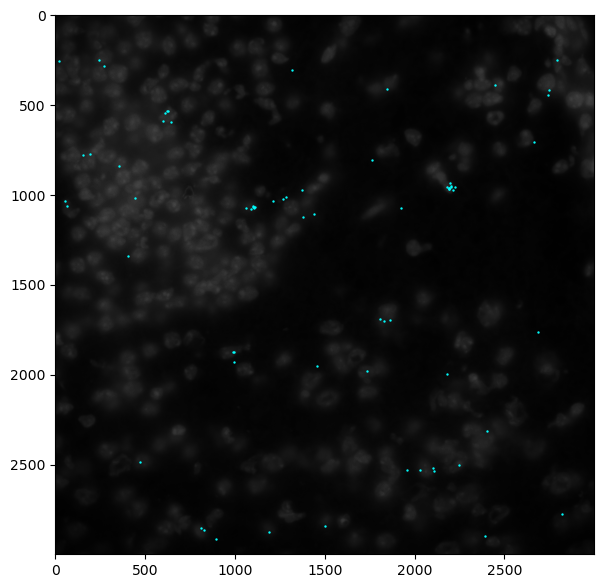

In [32]:
fig, ax = plt.subplots(figsize=(7,7))

x = [spots[i][2] for i in range(num_spots)]
y = [spots[i][1] for i in range(num_spots)]

# ax.imshow(imgs[34][4,10,:,:], cmap='gray', vmax=5000)
ax.imshow(imgs[37][3,10,:,:], cmap='gray', vmax=15000)

ax.scatter(x, y, s=0.5, c='cyan')

# plt.savefig(r'C:\Users\zgibbs\cellpose\HCT116_300CRE\figures\CRE016_fov034_yellowgreen.pdf')
plt.show()

In [265]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

import torch
torch.cuda.is_available()

True

In [266]:
torch.cuda.get_device_name(0)

'NVIDIA RTX A6000'

##### Segment FOV to provide cell masks

In [299]:
from cellpose import models, io
from tqdm import tqdm
import torch

# DEFINE CELLPOSE MODEL
# model_type='cyto2' or pretrained_model='<path_to_model>'
# pretrained_model=r'C:\Users\zgibbs\cellpose\HCT116_polyA_230320'

model = models.CellposeModel(gpu=True, model_type='cyto2',
                             device=torch.device(0))

masks, flows, styles = model.eval(imgs[34][3,10,:,:], channels=[0,0], diameter=250)

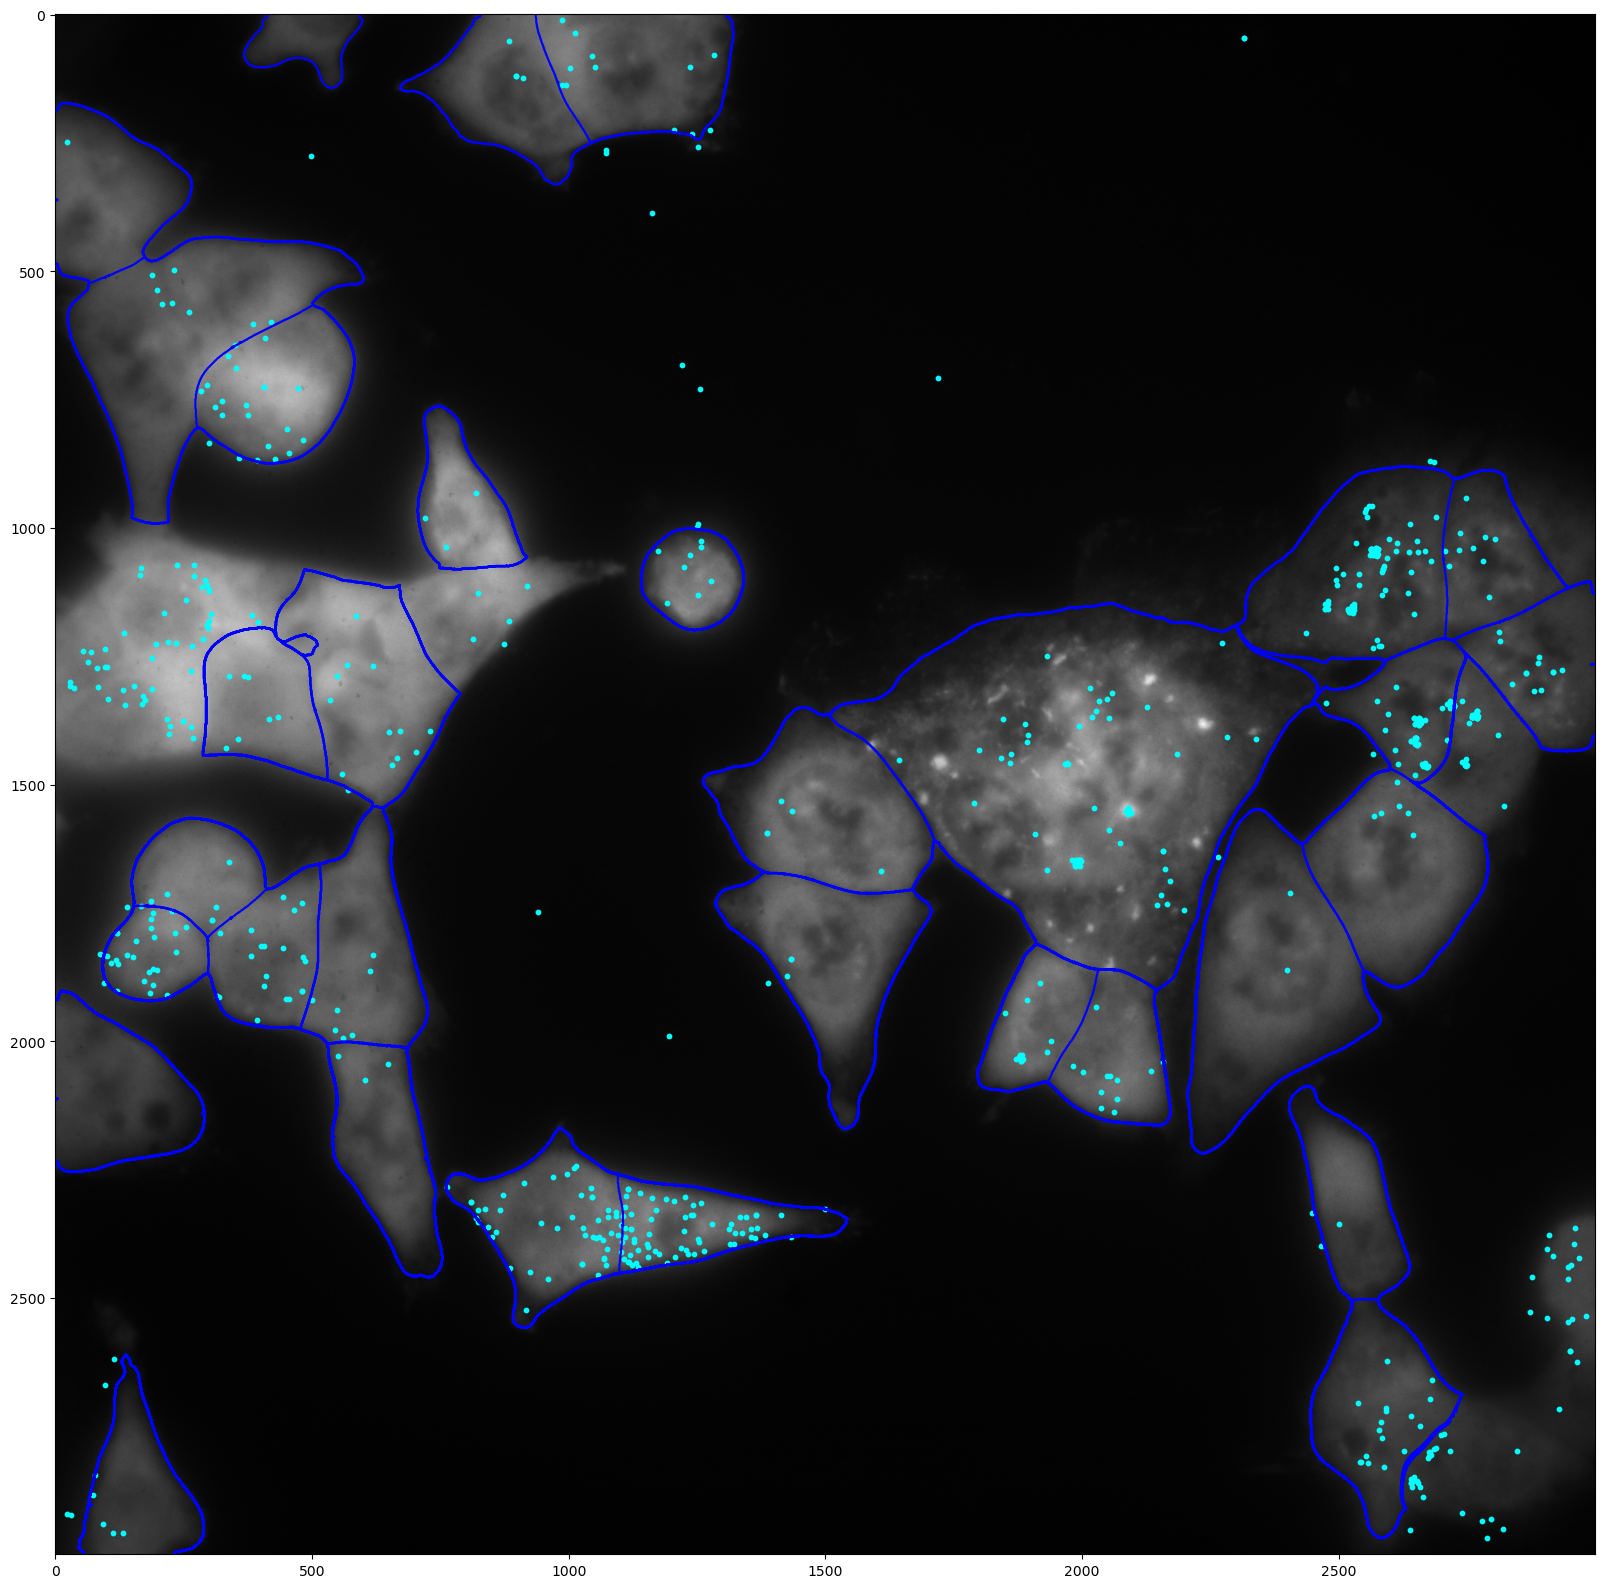

In [321]:
fig, ax = plt.subplots(figsize=(20,20))

ax.imshow(imgs[34][3,10,:,:], cmap='gray')
ax.contour(masks, [0.5+x for x in np.unique(masks)], colors='b')
x = [spots[i][3][2] for i in range(num_spots)]
y = [spots[i][3][1] for i in range(num_spots)]
ax.scatter(x, y, s=10, c='cyan')

# plt.savefig(r'C:\Users\zgibbs\cellpose\HCT116_300CRE\figures\CRE280_fov034', dpi=600)
plt.show()

In [108]:
# cell by gene matrix??
cbg = np.load('Y:\Zane_phpeb3week20CRE_6_1_2024_dataFrames\df_CREV2.pkl', allow_pickle=True)

In [175]:
cbg_clean

,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,...,blank038,blank039,blank040,blank041,blank042,blank043,blank044,blank045,blank046,total transcripts
0,3.0,21.0,10.0,1.0,3.0,0.0,1.0,9.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0
12,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0
26,0.0,0.0,1.0,1.0,0.0,0.0,10.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,12.0
28,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353000435,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
353000450,5.0,4.0,0.0,2.0,9.0,0.0,2.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44.0
353000462,1.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0
353000498,0.0,6.0,1.0,1.0,1.0,0.0,0.0,7.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0


In [109]:
cbg['total transcripts'] = cbg.iloc[:,:20].sum(axis=1)

cbg_clean = cbg[(cbg['total transcripts'] > 5) & (cbg['total transcripts'] < 150)]

from scipy import stats
import pandas as pd

res_total = []

for cre in cbg_clean.columns[:20]:
    res = stats.linregress(cbg_clean['total transcripts'], cbg_clean[cre])
    res_total.append(res)

y = [res_total[i].slope for i in range(20)]

yerr = [res_total[i].stderr*1.96 for i in range(20)]

d_full = pd.DataFrame(list(zip(cbg_clean.columns[:20], y, yerr)), columns = ['id', 'score', 'stderr'])

d_full_sorted = d_full.sort_values('score', axis=0, ascending=False)

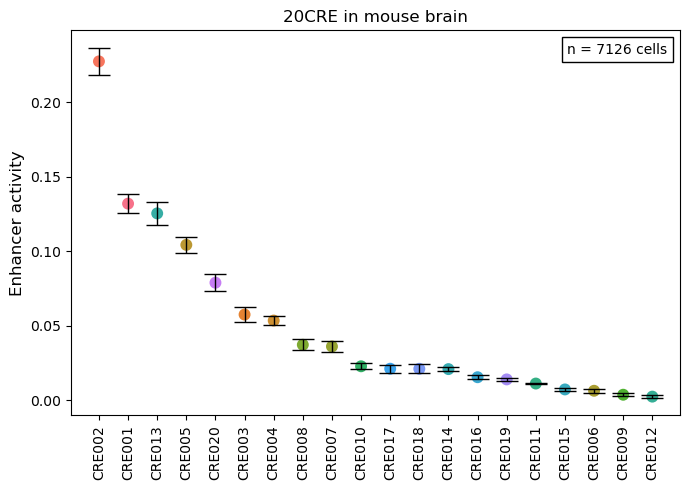

In [110]:
# Plot the enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(range(0,20), d_full_sorted['score'], marker='o', c=[colors[i] for i in d_full_sorted['id']], s=50, lw=1.5)
ax.errorbar(range(0,20), d_full_sorted['score'], d_full_sorted['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
ax.set_xticks(range(0,20))
ax.set_xticklabels(d_full_sorted['id'])
plt.xticks(rotation=90)
ax.set_ylabel('Enhancer activity', fontsize=12)
ax.set_title('20CRE in mouse brain')
# ax.set_xlabel('CREs', fontsize=12)

numcells = len(cbg_clean)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

plt.tight_layout()
# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/rep1_activity_240607.pdf')
plt.show()

In [87]:
colors = {'CRE001' : '#f77189',
        'CRE002' : '#f7755d',
        'CRE003' : '#e68332',
        'CRE004' : '#ce9032',
        'CRE005' : '#bb9832',
        'CRE006' : '#aa9e31',
        'CRE007' : '#97a431',
        'CRE008' : '#7eaa31',
        'CRE009' : '#50b131',
        'CRE010' : '#32b166',
        'CRE011' : '#34af84',
        'CRE012' : '#35ae96',
        'CRE013' : '#36ada4',
        'CRE014' : '#37abb1',
        'CRE015' : '#38aabf',
        'CRE016' : '#39a7d0',
        'CRE017' : '#3ba3ec',
        'CRE018' : '#7a98f4',
        'CRE019' : '#a48cf4',
        'CRE020' : '#c67df4',
        'blank1' : '#e866f4',
        'blank2' : '#f561dd',
        'blank3' : '#f668c2',
        'blank4' : '#f66ca8'}

In [111]:
all_cbg_rep1 = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_CRE_10_12_2023.csv')

all_cbg_rep1['total transcripts'] = all_cbg_rep1.iloc[:,1:21].sum(axis=1)

from scipy import stats

res_total_HCT116 = []

for cre in all_cbg_rep1.columns[1:21]:
    res_HCT116 = stats.linregress(all_cbg_rep1['total transcripts'], all_cbg_rep1[cre])
    res_total_HCT116.append(res_HCT116)

y_HCT116 = [res_total_HCT116[i].slope for i in range(20)]
yerr_HCT116 = [res_total_HCT116[i].stderr*1.96 for i in range(20)]
d_full_HCT116 = pd.DataFrame(list(zip(all_cbg_rep1.columns[1:21], y_HCT116, yerr_HCT116)), columns = ['id', 'score', 'stderr'])
d_full_sorted_HCT116 = d_full_HCT116.sort_values('score', axis=0, ascending=False)

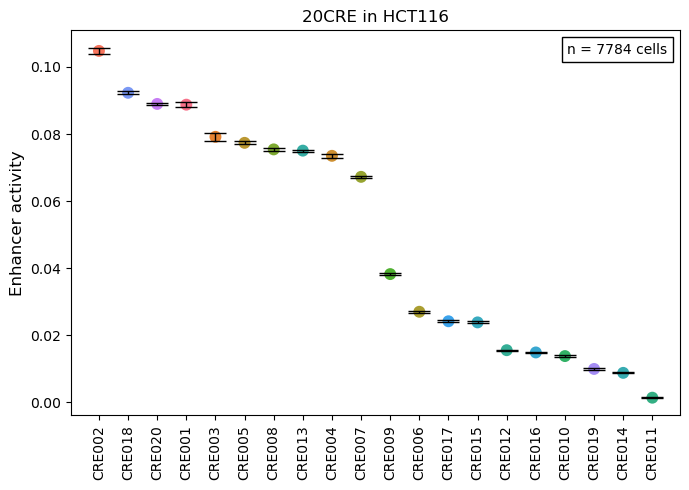

In [112]:
# Plot the enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(range(0,20), d_full_sorted_HCT116['score'], marker='o', c=[colors[i] for i in d_full_sorted_HCT116['id']], s=50, lw=1.5)
ax.errorbar(range(0,20), d_full_sorted_HCT116['score'], d_full_sorted_HCT116['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
ax.set_xticks(range(0,20))
ax.set_xticklabels(d_full_sorted_HCT116['id'])
plt.xticks(rotation=90)
ax.set_ylabel('Enhancer activity', fontsize=12)
ax.set_title('20CRE in HCT116')
# ax.set_xlabel('CREs', fontsize=12)

numcells = len(all_cbg_rep1)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

plt.tight_layout()
# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/rep1_activity_240607.pdf')
plt.show()

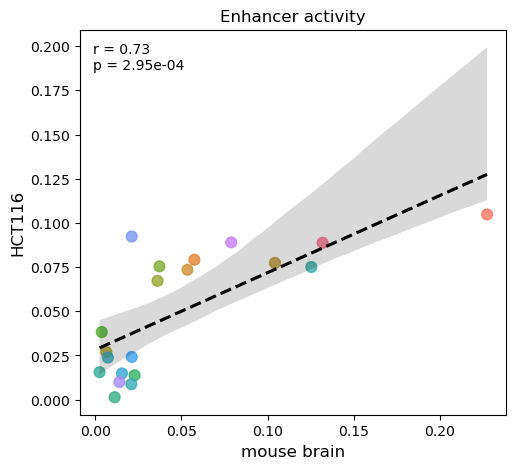

In [114]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = d_full['score']
y = d_full_HCT116['score']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in d_full['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('HCT116', fontsize=12)
ax.set_xlabel('mouse brain', fontsize=12)
ax.set_title('Enhancer activity')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/rep1_vs_rep2_activity_240607.pdf')
plt.show()

### Visualize CRE positive cells in mouse brain

In [2]:
# Load cell by gene matrix for CREs
CRE_cbg = np.load('Y:\Zane_phpeb3week20CRE_6_1_2024_dataFrames\df_CREV2.pkl', allow_pickle=True)
CRE_cbg['total transcripts'] = CRE_cbg.iloc[:,:20].sum(axis=1)
CRE_cbg

,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,...,blank038,blank039,blank040,blank041,blank042,blank043,blank044,blank045,blank046,total transcripts
0,3.0,21.0,10.0,1.0,3.0,0.0,1.0,9.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0
12,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353000706,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
353000759,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
353000788,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
353000878,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Load cell by gene matrix for marker genes
gene_cbg = np.load('Y:/Zane_phpeb3week20CRE_6_1_2024_dataFrames/dff_Eth1V2.pkl', allow_pickle=True)
gene_cbg

,2610528A11Rik,A1cf,A230050P20Rik,Abca8a,Abcb1b,Abcb4,Abcg1,Abhd15,Adamts1,Adamts9,...,blank0338-L1,blank0339-L1,blank0340-L1,blank0341-L1,blank0342-L1,blank0343-L1,blank0344-L1,blank0345-L1,blank0346-L1,blank0347-L1
Conv_zscan__000_112,0.0,0.0,0.0,1.0,1.0,2.0,2.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan__000_128,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan__000_133,0.0,0.0,6.0,1.0,1.0,3.0,0.0,0.0,1.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan__000_145,0.0,0.0,0.0,3.0,0.0,0.0,4.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan__000_17,0.0,0.0,6.0,0.0,2.0,2.0,3.0,0.0,1.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Conv_zscan__351_35100733,0.0,0.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan__351_35100759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan__351_35100819,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Conv_zscan__352_35200818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Load cell metadata 
cell_data = np.load('Y:/Zane_phpeb3week20CRE_6_1_2024_dataFrames/cell_df_Eth1V2.pkl', allow_pickle=True)
cell_data

,cell_id,volm,zc,xc,yc,z_um_abs,x_um_abs,y_um_abs
Conv_zscan__000_112,112.0,27316.0,9.899034,532.249890,552.196844,9.899034,235.834362,4895.734657
Conv_zscan__000_128,128.0,22227.0,6.737751,600.349170,292.755343,6.737751,265.343142,4783.313465
Conv_zscan__000_133,133.0,30771.0,9.308180,624.007572,626.533912,9.308180,275.594801,4927.946395
Conv_zscan__000_145,145.0,23201.0,9.111202,692.264040,342.984958,9.111202,305.171694,4805.078962
Conv_zscan__000_17,17.0,28112.0,6.682555,39.670532,314.867210,6.682555,22.389875,4792.894979
...,...,...,...,...,...,...,...,...
Conv_zscan__351_35100733,35100733.0,5384.0,16.291790,506.670134,501.093053,16.291790,535.873902,4873.590362
Conv_zscan__351_35100759,35100759.0,5605.0,17.518466,176.095450,628.223194,17.518466,392.629281,4928.678394
Conv_zscan__351_35100819,35100819.0,10088.0,17.171590,92.750000,188.968279,17.171590,356.514030,4738.340455
Conv_zscan__352_35200818,35200818.0,2509.0,16.241530,306.657633,364.335592,16.241530,138.947365,4814.763939


(-275.2027050065057, 5818.484932367087, -298.55091354088944, 7703.33945160367)

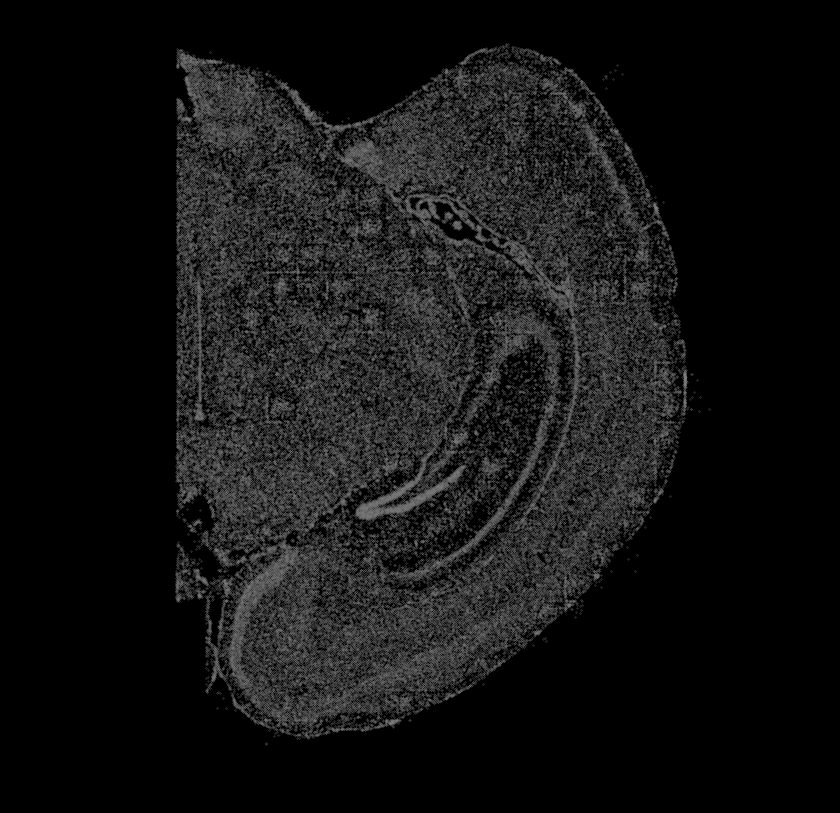

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10), facecolor='k')
x, y = cell_data['x_um_abs'], cell_data['y_um_abs']
ax.scatter(x, y, c='gray', s=0.05)
# ax = plt.gca()
ax.set_facecolor('k')
plt.axis('equal')

In [6]:
# little function to correct the cell ids from CRE_cbg to match those from cell_data
def refine_cell_ids(my_list, index):
    return [x[:index] + x[index + 1:] for x in my_list]
    
# Create list of cell ids for CRE-positive cells
CRE_counts = CRE_cbg[(CRE_cbg['total transcripts'] > 5)]
idx = CRE_counts.index
idx2 = idx.to_list()
idx2 = [str(i) for i in idx2]
idx3 = refine_cell_ids(idx2, -4)
idx3 = [float(i) for i in idx3]
CRE_counts['cell_id'] = idx3

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_33044\3529826497.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CRE_counts['cell_id'] = idx3


In [7]:
# Create new dataframe of cell metadata for the CRE-positive cells
pos_cells = cell_data[cell_data['cell_id'].isin(CRE_counts['cell_id'])]
num_cells = len(pos_cells)
print(str(num_cells) + ' cells')

6893 cells


(-275.2027050065057, 5818.484932367087, 7703.33945160367, -298.55091354088944)

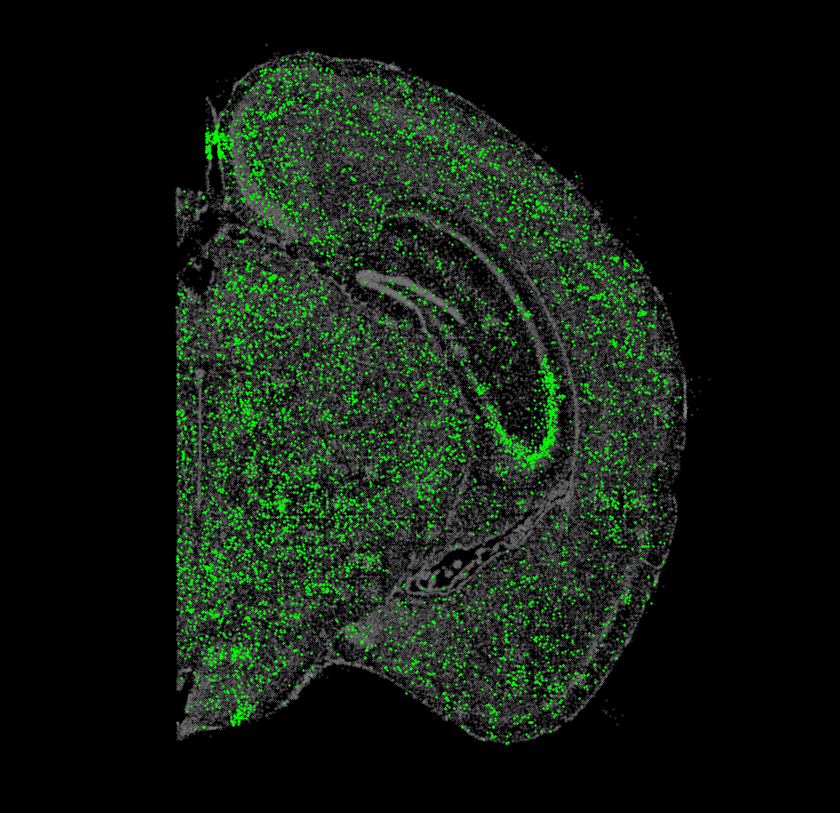

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10), facecolor='k')
ax.scatter(cell_data['x_um_abs'], cell_data['y_um_abs'], c='gray', s=0.05)
x = pos_cells['x_um_abs']
y = pos_cells['y_um_abs']
ax.scatter(x, y, c='lime', s=0.5)
plt.gca().invert_yaxis()
ax.set_facecolor('k')
plt.axis('equal')

In [9]:
import scanpy as sc
import anndata as adata
adata_merfish = adata.AnnData(gene_cbg.iloc[:,:348])
adata_merfish.obsm['spatial'] = cell_data.iloc[:,-2:]

In [10]:
sc.pp.normalize_per_cell(adata_merfish, counts_per_cell_after=2e3)

In [11]:
sc.pp.log1p(adata_merfish)

In [12]:
sc.pp.pca(adata_merfish, n_comps=15)

In [13]:
sc.pp.neighbors(adata_merfish)

In [14]:
sc.tl.umap(adata_merfish)

In [15]:
seed = np.random.randint(0, 2**32 - 1, dtype=np.int64 )

In [ ]:
sc.tl.leiden(
    adata_merfish,
    key_added="clusters",
    resolution=0.5,
    n_iterations=1,
    flavor="igraph",
    directed=False,
    random_state=23
)

Exception ignored in: <class 'ValueError'>
Traceback (most recent call last):
  File "numpy\\random\\mtrand.pyx", line 780, in numpy.random.mtrand.RandomState.randint
  File "numpy\\random\\_bounded_integers.pyx", line 1423, in numpy.random._bounded_integers._rand_int32
ValueError: high is out of bounds for int32
Exception ignored in: <class 'ValueError'>
Traceback (most recent call last):
  File "numpy\\random\\mtrand.pyx", line 780, in numpy.random.mtrand.RandomState.randint
  File "numpy\\random\\_bounded_integers.pyx", line 1423, in numpy.random._bounded_integers._rand_int32
ValueError: high is out of bounds for int32
Exception ignored in: <class 'ValueError'>
Traceback (most recent call last):
  File "numpy\\random\\mtrand.pyx", line 780, in numpy.random.mtrand.RandomState.randint
  File "numpy\\random\\_bounded_integers.pyx", line 1423, in numpy.random._bounded_integers._rand_int32
ValueError: high is out of bounds for int32
Exception ignored in: <class 'ValueError'>
Traceback (m

In [440]:
specks = pd.DataFrame(specks)

In [ ]:
gene_cbg.sum().median()

In [842]:
test = sc.read_h5ad('Y:\Zane_phpeb3week20CRE_6_1_2024_dataFrames\scdata_Zane_gene_expr_20CRE.h5ad')

In [843]:
test

AnnData object with n_obs × n_vars = 90764 × 348
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_raw', 'X_spatial', 'X_umap'
    obsp: 'connectivities', 'distances'

In [847]:
coordinates = cell_data.iloc[:,-2:]

In [848]:
coordinates

,x_um_abs,y_um_abs
Conv_zscan__000_112,235.834362,4895.734657
Conv_zscan__000_128,265.343142,4783.313465
Conv_zscan__000_133,275.594801,4927.946395
Conv_zscan__000_145,305.171694,4805.078962
Conv_zscan__000_17,22.389875,4792.894979
...,...,...
Conv_zscan__351_35100733,535.873902,4873.590362
Conv_zscan__351_35100759,392.629281,4928.678394
Conv_zscan__351_35100819,356.514030,4738.340455
Conv_zscan__352_35200818,138.947365,4814.763939
